# Model evaluation — three-model backtest

Side-by-side backtest of the three forecasting models on the 12 raw ND-GAIN
sub-indicators (`Readiness`/`Vulnerability`/`CompositeRisk` are derived columns
and excluded):

| Key | Model | Source |
|---|---|---|
| `arima` | ARIMA, order chosen per (country, indicator) from its own PACF/ACF | `model/old_models/arima_all_indicators.py` |
| `ets` | Holt's linear trend, damped vs non-damped by AIC | `model/prediction/ETS_all_indicators.py` |
| `arima_shared_order` | ARIMA, one order per indicator (lowest mean AIC across countries) | `model/old_models/second_arima/second_arima.py` |

**Methodology:** for every country the last 5 years are held out; each model is
fitted on the preceding history and forecasts the held-out window. MAE/RMSE are
computed per (country, indicator, model). The backtest machinery lives in
[`eval_utils.py`](eval_utils.py) so the imputation-comparison notebook can reuse it.

Note: the shared-order model does not forecast **Exposure** (by its own
methodology), so that indicator only has results for the other two models.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import notebooks.model_evaluation.eval_utils as eval_utils
from notebooks.model_evaluation.eval_utils import INDICATORS, MODEL_LABELS, TEST_YEARS

pd.set_option("display.float_format", "{:.4f}".format)

MODEL_COLORS = {
    "arima": "#2a78d6",
    "ets": "#eb6834",
    "arima_shared_order": "#1baf7a",
}
ACTUAL_COLOR = "#0b0b0b"

## Run backtest

All three models on all countries. **This takes ~10–15 minutes** (progress is
printed every 10 countries). Console noise from the models is captured; the
ARIMA convergence-fallback count (see `fit_arima`'s pure-AR fallback) is
reported afterwards as a diagnostic.

In [2]:
df = pd.read_csv(ROOT / "data" / "data_preprocessed" / "processed_data.csv")

results, preds, info = eval_utils.run_backtests(df)

print(f"Result rows: {len(results)}  |  failed fits: {results['error'].notna().sum()}")
print(f"ARIMA convergence fallbacks (per-series model): {info['arima_convergence_fallbacks']}")
print("Shared-order selection:", info["shared_orders"])
results.head()

Result rows: 6510  |  failed fits: 0
ARIMA convergence fallbacks (per-series model): 631
Shared-order selection: {'Capacity': (2, 0, 0), 'Economic': (2, 0, 0), 'Ecosystems': (2, 0, 0), 'Food': (2, 0, 0), 'Governance': (2, 0, 0), 'Habitat': (2, 0, 1), 'Health': (2, 0, 0), 'Infrastructure': (2, 0, 0), 'Sensitivity': (2, 0, 0), 'Social': (2, 0, 0), 'Water': (2, 0, 0)}


,country,indicator,model,mae,rmse,error
0,AFG,Capacity,arima,0.0407,0.0408,None
1,AFG,Capacity,ets,0.0168,0.0183,None
2,AFG,Economic,arima,0.0149,0.0162,None
3,AFG,Economic,ets,0.0429,0.0454,None
4,AFG,Ecosystems,arima,0.0011,0.0012,None


## Results — MAE tables

In [3]:
valid = results[results["error"].isna()]

overall = (
    valid.groupby("model")[["mae", "rmse"]]
    .agg(["mean", "median"])
    .rename(index=MODEL_LABELS)
)
print(f"Overall across all (country, indicator) pairs, {TEST_YEARS}-year holdout:")
overall

Overall across all (country, indicator) pairs, 5-year holdout:


mae          rmse       
                           mean median   mean median
model                                               
ARIMA (per-series order) 0.0154 0.0075 0.0168 0.0084
ARIMA (shared order)     0.0165 0.0084 0.0182 0.0097
ETS (Holt)               0.0144 0.0062 0.0159 0.0072

In [4]:
by_indicator = (
    valid.groupby(["indicator", "model"])["mae"].mean().unstack()
    .rename(columns=MODEL_LABELS)
)

def highlight_winner(row):
    winner = row.idxmin()  # lower MAE wins; NaN (Exposure / shared order) is skipped
    return ["background-color: lightgreen" if col == winner else "" for col in row.index]

print("Mean MAE per indicator (green = best model):")
by_indicator.style.apply(highlight_winner, axis=1).format("{:.6f}", na_rep="—")

Mean MAE per indicator (green = best model):


model,ARIMA (per-series order),ARIMA (shared order),ETS (Holt)
indicator,,,
Capacity,0.018352,0.018205,0.016503
Economic,0.028001,0.027405,0.025280
Ecosystems,0.003156,0.003632,0.002960
Exposure,0.000004,—,0.000000
Food,0.010863,0.010859,0.010622
Governance,0.036283,0.035086,0.032890
Habitat,0.007861,0.008111,0.009131
Health,0.015548,0.014825,0.016697
Infrastructure,0.032868,0.033174,0.031134


In [5]:
pivot = valid.pivot_table(index=["country", "indicator"], columns="model", values="mae")

three_way = pivot.dropna()
print(f"Three-way win rate (lower MAE), {len(three_way)} (country, indicator) pairs "
      "where all three models fitted (Exposure excluded):")
print(three_way.idxmin(axis=1).map(MODEL_LABELS).value_counts().to_string(), "\n")

two_way = pivot[["arima", "ets"]].dropna()
winner = np.where(two_way["arima"] < two_way["ets"], "arima",
                  np.where(two_way["arima"] > two_way["ets"], "ets", "tie"))
print(f"Head-to-head ARIMA (per-series) vs ETS, all 12 indicators ({len(two_way)} pairs):")
print(pd.Series(winner).value_counts().to_string())

Three-way win rate (lower MAE), 2046 (country, indicator) pairs where all three models fitted (Exposure excluded):
ETS (Holt)                  1056
ARIMA (per-series order)     500
ARIMA (shared order)         490 

Head-to-head ARIMA (per-series) vs ETS, all 12 indicators (2232 pairs):
ets      1300
arima     911
tie        21


In [6]:
failed = results[results["error"].notna()]
print(f"Failed fits: {len(failed)} / {len(results)}")
if len(failed):
    display(failed[["country", "indicator", "model", "error"]].head(20))

Failed fits: 0 / 6510


## Forecast plots — held-out window

Cross-country average per indicator: actual trajectory (black) and each model's
average forecast over the held-out years. This visualizes exactly what the MAE
tables score. The dotted line marks the train/test split.

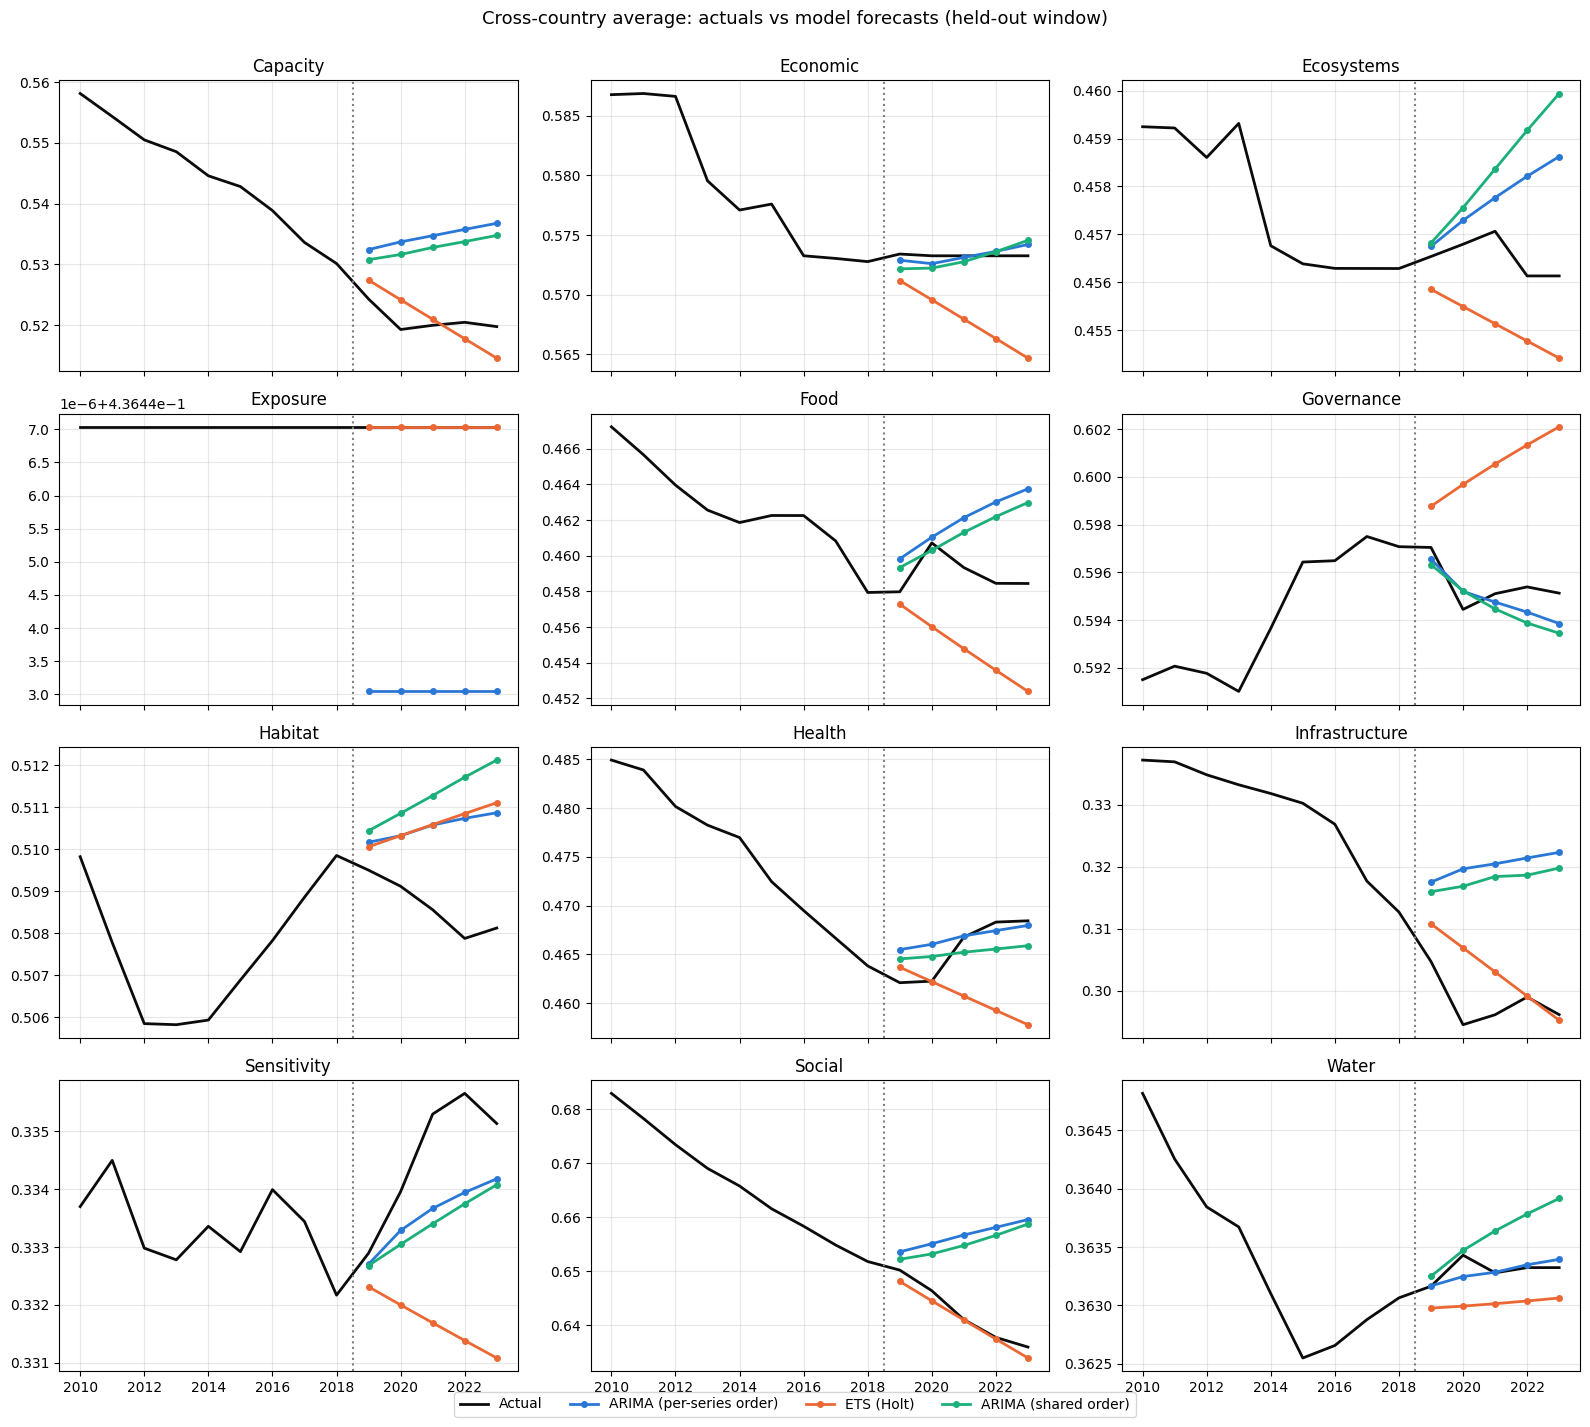

In [7]:
PLOT_FROM = 2010  # zoom the history so the 5-year test window stays readable

actual_avg = (
    df[df["Year"] >= PLOT_FROM]
    .groupby("Year")[[c for c in INDICATORS if c in df.columns]]
    .mean()
)
pred_avg = preds.groupby(["model", "indicator", "year"])["predicted"].mean()

split_year = preds["year"].min() - 0.5

fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharex=True)
for ax, indicator in zip(axes.flatten(), INDICATORS):
    ax.plot(actual_avg.index, actual_avg[indicator],
            color=ACTUAL_COLOR, linewidth=2, label="Actual")
    for model, color in MODEL_COLORS.items():
        if (model, indicator) in pred_avg.index.droplevel("year").drop_duplicates():
            line = pred_avg.loc[model, indicator]
            ax.plot(line.index, line.values, color=color, linewidth=2,
                    marker="o", markersize=4, label=MODEL_LABELS[model])
    ax.axvline(x=split_year, color="gray", linestyle=":", linewidth=1.5)
    ax.set_title(indicator)
    ax.grid(alpha=0.3)

handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Cross-country average: actuals vs model forecasts (held-out window)",
             y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

### Country drill-down

Same comparison for a single (country, indicator) — change the two constants
and re-run the cell.

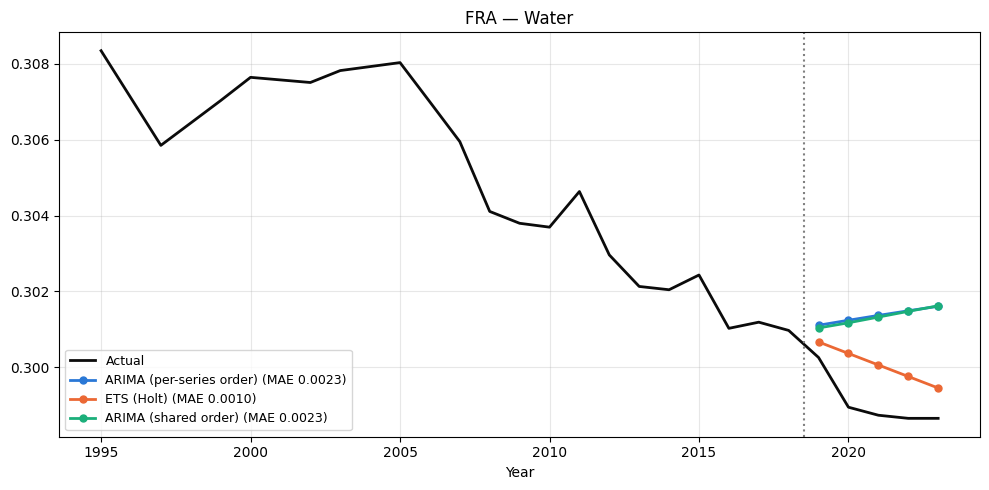

In [8]:
COUNTRY = "FRA"
INDICATOR = "Water"

history = df[df["Country"] == COUNTRY][["Year", INDICATOR]].dropna()
sub = preds[(preds["country"] == COUNTRY) & (preds["indicator"] == INDICATOR)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["Year"], history[INDICATOR],
        color=ACTUAL_COLOR, linewidth=2, label="Actual")
for model, color in MODEL_COLORS.items():
    line = sub[sub["model"] == model].sort_values("year")
    if len(line):
        mae = valid[(valid["country"] == COUNTRY) & (valid["indicator"] == INDICATOR)
                    & (valid["model"] == model)]["mae"]
        label = f"{MODEL_LABELS[model]} (MAE {mae.iloc[0]:.4f})" if len(mae) else MODEL_LABELS[model]
        ax.plot(line["year"], line["predicted"], color=color, linewidth=2,
                marker="o", markersize=5, label=label)
ax.axvline(x=split_year, color="gray", linestyle=":", linewidth=1.5)
ax.set_title(f"{COUNTRY} — {INDICATOR}")
ax.set_xlabel("Year")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()